In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
test_traj = np.loadtxt('./Forward Walkers/3/trajectory.dat')
np.savetxt('./Forward Walkers/3/testtrajectory0.dat',test_traj[:,0])
np.savetxt('./Forward Walkers/3/testtrajectory1.dat',test_traj[:,1])

In [3]:
np.array([-0.197787, -7.11328]) - np.array([-4.69781, -2.35826])

array([ 4.500023, -4.75502 ])

In [108]:
#extract one cycle
goup = False
stidx = 0
stopidx = 0
for i in range(len(test_traj)-1):
    if ((test_traj[i] < .5) and (test_traj[i+1]>=.5)):
        if not goup:
            goup = True
            stidx = i
        else:
            stopidx = i
            break
test_traj = test_traj[stidx:stopidx]

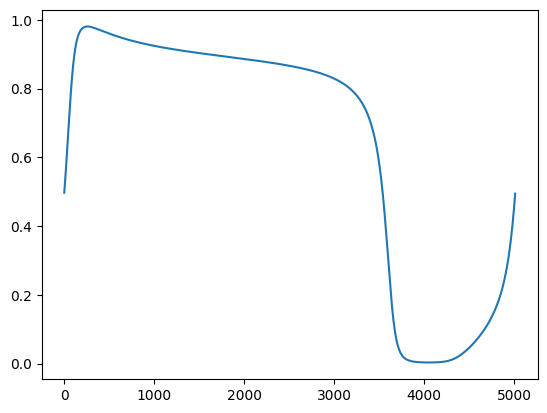

In [109]:
plt.plot(test_traj)
plt.show()

In [116]:
def rho(traj,lb,ub):
    drive_vals = np.where(
        traj < lb,
        lb - traj,
        np.where(traj > ub, ub - traj, 0)
    )
    return drive_vals
def calc_drive(traj, lb, ub):
    return float(np.average(rho(traj,lb,ub)))

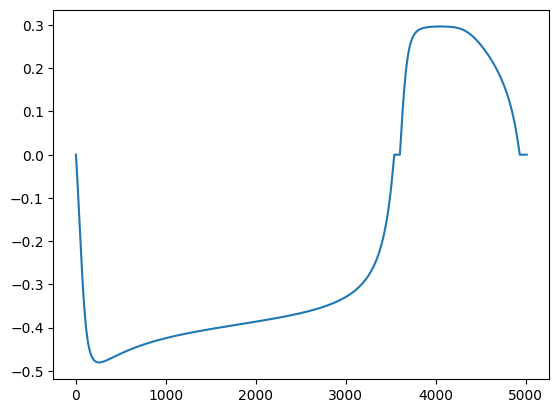

In [121]:
plt.plot(rho(test_traj,.3,.5))

In [117]:
print('old drive:', np.average(.5-test_traj))
calc_drive(test_traj,.5,.5)

old drive: -0.14532161644581917


-0.14532161644581917

In [124]:
def calc_beta(traj,lb):
    below = rho(traj[traj<lb],lb,1)
    below = lb - below
    beta = np.sum(below)
    return beta

In [125]:
calc_beta(test_traj,.5)

np.float64(141.47946601)

In [126]:
def calc_ub(traj,lb):
    beta = calc_beta(traj,lb)
    ub = 1-(beta/len(traj))
    return ub

Calculated: 0.9857137732967471


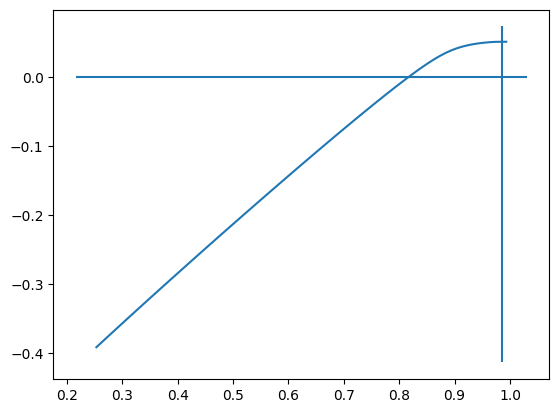

In [127]:
# lb = 0.67603991
lb = 0.25335463
ub = calc_ub(test_traj,lb)
print("Calculated:",ub)
test_ubs = np.arange(lb,1,0.01)
drives = np.zeros(len(test_ubs))
i = 0
for test_ub in test_ubs:
    drive = calc_drive(test_traj,lb,test_ub)
    drives[i] = drive
    i += 1
plt.plot(test_ubs,drives)
plt.vlines(ub,plt.ylim()[0],plt.ylim()[1])
plt.hlines(0,plt.xlim()[0],plt.xlim()[1])
plt.show()
